# Environmental Predictor Layers
## Part 2 of the GSMNP Detection Gap Project

A species distribution model needs two things: presence records (from notebook 01) and a set of environmental layers that describe habitat conditions across the landscape. This notebook builds that second piece — a stack of raster layers covering Great Smoky Mountains National Park and a 10 km buffer, all reprojected and resampled to a common grid.

The predictors are:

- **Climate** (4 layers) — PRISM 30-year average precipitation, max temperature, mean temperature, and min temperature. Already available locally at ~800 m resolution.
- **Elevation** — USGS 3DEP 1/3 arc-second (~10 m native), downsampled to 250 m. Critical predictor for the Smokies, which span 260 m to 2,025 m elevation across ~90 km.
- **Land cover** — NLCD 2021 at 30 m native, resampled to 250 m via nearest-neighbor. Captures forest type, agricultural and urban/suburban cover relevant to SLF establishment.

The output is `./data/env_stack/env_predictors.tif`, a 6-band GeoTIFF in EPSG:5070 (Conus Albers Equal Area) at 250 m resolution. Notebook 03 reads this stack to produce the suitability map.

**Target resolution: 250 m.** PRISM is ~800 m, so going finer than ~250 m creates false precision in climate — 27 sub-pixels would share identical climate values. Going coarser than ~250 m loses real topographic and land cover variation that matters for a park with 1,750 m of elevation relief. 250 m is a defensible middle ground.

**Target CRS: EPSG:5070 (NAD83 / Conus Albers).** Equal-area projection, standard for CONUS ecological work. Equal-area cells mean each pixel represents the same ground area — important for SDM predictions.

**A note on PRISM temperature units:** The local PRISM files store temperature in actual °C (range roughly -12 to 34), not in °C × 100. The cell below confirms this. No scaling is applied.

## Setup

`py3dep` and `pygeohydro` are part of the [HyRiver](https://hyriver.readthedocs.io/) project. They provide Python interfaces to USGS 3DEP elevation and NLCD land cover services. Neither is in the base container image, so we install them here. The install takes ~30 seconds and includes `xarray`, `rioxarray`, and related dependencies.

In [1]:
!pip install py3dep pygeohydro


Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 KB 449.3 kB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.2/62.2 KB 911.2 kB/s eta 0:00:000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 4.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 23.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.9/62.9 KB 1.3 MB/s eta 0:00:00:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.4/51.4 KB 839.1 kB/s eta 0:00:0000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 5.7 MB/s eta 0:00:0000:01:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.8/102.8 KB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.3/243.3 KB 8.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.2 MB/s eta 0:00:0000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.5/240.5 KB 7

## Imports

Importing `rioxarray` registers the `.rio` accessor on `xarray.DataArray`, which py3dep and pygeohydro use for their return types. It doesn't need to be called directly, but the import must happen before any HyRiver function is called.

In [3]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import geopandas as gpd
import rasterio
import rioxarray  # registers .rio accessor; must import before HyRiver functions
from affine import Affine
from rasterio.mask import mask as rio_mask
from rasterio.warp import reproject, Resampling
from rasterio.crs import CRS
import py3dep
from pygeohydro import nlcd_bygeom


## Study Extent and Target Grid

Every raster in the stack must share an identical grid — same CRS, same pixel size, same origin, same width and height. Rasterio's `reproject()` lets us specify a target transform and destination array shape explicitly, which forces this alignment regardless of source format or resolution. We define that target grid once here and reuse it for every layer.

The study extent is the GSMNP boundary polygon buffered by 10 km in EPSG:5070. Buffering in a projected (meter-based) CRS means the buffer distance is exact; buffering in degrees would give an ellipsoidal approximation that varies with latitude. The resulting bounds are then snapped to the 250 m grid — rounded outward so no study-area pixels are clipped — to produce clean integer grid dimensions.

Data fetching (elevation, land cover) uses a 15 km fetch buffer. The extra 5 km provides padding that gets trimmed during reprojection, preventing edge artifacts where the resampler would otherwise extrapolate from nothing.

In [4]:
boundary = gpd.read_file('./data/nps/BOUNDARY_PY.shp')
boundary_albers = boundary.to_crs('EPSG:5070')

# Study area: 10 km buffer for prediction stack
study_poly  = boundary_albers.buffer(10_000).union_all()
study_gdf   = gpd.GeoDataFrame(geometry=[study_poly], crs='EPSG:5070')

# Fetch buffer: 15 km for DEM/NLCD requests (trimmed after reprojection)
fetch_poly  = boundary_albers.buffer(15_000).union_all()
fetch_gdf   = gpd.GeoDataFrame(geometry=[fetch_poly], crs='EPSG:5070')

# Snap target bounds to 250 m grid (round outward)
RES   = 250
b     = study_gdf.total_bounds  # xmin, ymin, xmax, ymax in EPSG:5070
xmin  = np.floor(b[0] / RES) * RES
ymin  = np.floor(b[1] / RES) * RES
xmax  = np.ceil(b[2]  / RES) * RES
ymax  = np.ceil(b[3]  / RES) * RES
W     = int((xmax - xmin) / RES)
H     = int((ymax - ymin) / RES)

TARGET_CRS = CRS.from_epsg(5070)
# North-up raster: positive x-step, negative y-step, origin at top-left
target_xf  = Affine(RES, 0, xmin, 0, -RES, ymax)

print(f'Study bounds (EPSG:5070 m):  ({xmin:.0f}, {ymin:.0f}) → ({xmax:.0f}, {ymax:.0f})')
print(f'Grid: {W} cols × {H} rows at {RES} m/pixel')
print(f'Coverage: ~{W*RES/1000:.0f} km × {H*RES/1000:.0f} km')


Study bounds (EPSG:5070 m):  (1064000, 1436750) → (1173250, 1508250)
Grid: 437 cols × 286 rows at 250 m/pixel
Coverage: ~109 km × 72 km


## PRISM Climate Layers

The four PRISM layers in `./data/prism/` are 30-arc-second (~800 m) rasters in NAD83 geographic coordinates (EPSG:4269), covering the continental US. They represent 30-year averages (1991–2020) computed from station records using PRISM's elevation-aware regression model.

A few things worth checking before processing:

- **CRS** — NAD83 geographic, not WGS84. The difference is sub-meter at this scale and rasterio handles it transparently, but it's worth knowing.
- **Nodata value** — stored as -9999 in the raster header. These become NaN in the output.
- **Temperature units** — the PRISM GeoTIFFs store actual °C, not °C × 100. The value range below confirms this.

In [5]:
prism_dir   = Path('./data/prism')
prism_files = {
    'ppt':   prism_dir / 'prism_ppt_us_30s_2020_avg_30y.tif',
    'tmax':  prism_dir / 'prism_tmax_us_30s_2020_avg_30y.tif',
    'tmean': prism_dir / 'prism_tmean_us_30s_2020_avg_30y.tif',
    'tmin':  prism_dir / 'prism_tmin_us_30s_2020_avg_30y.tif',
}
prism_units = {'ppt': 'mm', 'tmax': '°C', 'tmean': '°C', 'tmin': '°C'}

for name, path in prism_files.items():
    with rasterio.open(path) as src:
        data = src.read(1, masked=True)
        res_deg  = src.res[0]
        res_m    = res_deg * 111_000  # rough conversion at mid-latitudes
        print(f'{name}:')
        print(f'  CRS:        EPSG:{src.crs.to_epsg()}')
        print(f'  Resolution: {res_deg}° (~{res_m:.0f} m)')
        print(f'  Shape:      {src.width} × {src.height}')
        print(f'  Nodata:     {src.nodata}')
        print(f'  Value range: {float(data.min()):.2f} – {float(data.max()):.2f} {prism_units[name]}')
        print()


ppt:
  CRS:        EPSG:4269
  Resolution: 0.00833333333° (~925 m)
  Shape:      7025 × 3105
  Nodata:     -9999.0
  Value range: 45.54 – 6210.98 mm

tmax:
  CRS:        EPSG:4269
  Resolution: 0.0083333333° (~925 m)
  Shape:      7025 × 3105
  Nodata:     -9999.0
  Value range: -6.41 – 33.43 °C

tmean:
  CRS:        EPSG:4269
  Resolution: 0.0083333333° (~925 m)
  Shape:      7025 × 3105
  Nodata:     -9999.0
  Value range: -11.57 – 25.69 °C

tmin:
  CRS:        EPSG:4269
  Resolution: 0.0083333333° (~925 m)
  Shape:      7025 × 3105
  Nodata:     -9999.0
  Value range: -16.73 – 23.55 °C



## Clipping and Reprojecting PRISM

Each PRISM raster is a full continental US extent — about 7,800 × 4,800 pixels. We only need a small window over the Smokies. The approach:

1. Reproject the study area polygon to the PRISM raster's CRS (EPSG:4269), then use `rasterio.mask.mask()` to clip. This avoids reprojecting the entire continental raster — we reduce the data volume first, then reproject the small clip.
2. Reproject the clipped array to the target grid (EPSG:5070, 250 m) using bilinear resampling. Bilinear interpolation is appropriate for smoothly varying continuous fields like temperature and precipitation.

The same function handles all four PRISM layers.

In [6]:
out_dir = Path('./data/env_stack')
out_dir.mkdir(exist_ok=True)


def clip_and_reproject(src_path, dst_path, mask_gdf,
                        tgt_xf, tgt_crs, tgt_w, tgt_h,
                        resample=Resampling.bilinear):
    """Clip a raster to mask_gdf, reproject to target grid, save, return 2-D array."""
    with rasterio.open(src_path) as src:
        geoms    = [g.__geo_interface__ for g in mask_gdf.to_crs(src.crs).geometry]
        clipped, clip_xf = rio_mask(src, geoms, crop=True)
        src_crs  = src.crs
        src_nd   = src.nodata

    out = np.full((1, tgt_h, tgt_w), np.nan, dtype=np.float32)
    reproject(
        source=clipped.astype(np.float32),
        destination=out,
        src_transform=clip_xf,
        src_crs=src_crs,
        src_nodata=src_nd,
        dst_transform=tgt_xf,
        dst_crs=tgt_crs,
        dst_nodata=np.nan,
        resampling=resample,
    )

    meta = {'driver': 'GTiff', 'dtype': 'float32', 'count': 1,
            'crs': tgt_crs, 'transform': tgt_xf,
            'width': tgt_w, 'height': tgt_h, 'nodata': np.nan}
    with rasterio.open(dst_path, 'w', **meta) as f:
        f.write(out)
    return out[0]


# Process all four PRISM layers
prism_arrays = {}
for name, src_path in prism_files.items():
    arr = clip_and_reproject(
        src_path, out_dir / f'{name}.tif', study_gdf,
        target_xf, TARGET_CRS, W, H
    )
    prism_arrays[name] = arr
    print(f'{name:6s}: {np.sum(~np.isnan(arr)):,} valid pixels  '
          f'range [{np.nanmin(arr):.2f}, {np.nanmax(arr):.2f}] {prism_units[name]}')


ppt   : 81,715 valid pixels  range [1060.60, 2198.07] mm
tmax  : 81,715 valid pixels  range [11.75, 21.20] °C
tmean : 81,715 valid pixels  range [7.04, 15.03] °C
tmin  : 81,715 valid pixels  range [2.33, 9.06] °C


## Elevation — USGS 3DEP

Elevation is one of the most important predictors for SLF in the Smokies. The park spans from river valleys at ~260 m to Clingmans Dome at 2,025 m. Temperature, frost frequency, and plant community composition all change substantially across that gradient.

`py3dep` fetches elevation from the USGS 3D Elevation Program (3DEP), which covers the US at 1/3 arc-second (~10 m). We request data for the 15 km fetch buffer and save the raw tile as a checkpoint before reprojecting to the target grid.

The raw DEM comes back as an `xarray.DataArray` in EPSG:4326. `rioxarray`'s `.rio.to_raster()` saves it as a GeoTIFF. The following cell then reprojects from that file to the target grid.

**If the 3DEP service is unavailable**, the raw DEM file from a previous run will still be present in `./data/env_stack/dem_raw.tif` and the reproject cell below can run independently.

In [7]:
# Fetch extent as (west, south, east, north) in WGS84
fetch_bounds = tuple(fetch_gdf.to_crs('EPSG:4326').total_bounds)
print(f'Fetching DEM for bbox: {[f"{v:.4f}" for v in fetch_bounds]}')

dem_da = py3dep.get_dem(fetch_bounds, crs='EPSG:4326', resolution=10)

# rioxarray .rio accessor: write CRS to file metadata before saving
if dem_da.rio.crs is None:
    dem_da = dem_da.rio.write_crs('EPSG:4326')

dem_raw_path = out_dir / 'dem_raw.tif'
dem_da.rio.to_raster(str(dem_raw_path))
print(f'Saved dem_raw.tif  shape={dem_da.shape}  '
      f'range=[{float(dem_da.min()):.0f}, {float(dem_da.max()):.0f}] m')


Fetching DEM for bbox: ['-84.1808', '35.2950', '-82.8310', '35.9753']
Saved dem_raw.tif  shape=(10246, 14587)  range=[197, 2025] m


In [8]:
with rasterio.open(str(dem_raw_path)) as src:
    src_data  = src.read(1).astype(np.float32)
    src_xf    = src.transform
    src_crs   = src.crs
    src_nd    = src.nodata

out = np.full((1, H, W), np.nan, dtype=np.float32)
reproject(
    source=src_data[np.newaxis],
    destination=out,
    src_transform=src_xf,
    src_crs=src_crs,
    src_nodata=src_nd,
    dst_transform=target_xf,
    dst_crs=TARGET_CRS,
    dst_nodata=np.nan,
    resampling=Resampling.bilinear,
)
elev_arr = out[0]

meta = {'driver': 'GTiff', 'dtype': 'float32', 'count': 1,
        'crs': TARGET_CRS, 'transform': target_xf,
        'width': W, 'height': H, 'nodata': np.nan}
with rasterio.open(str(out_dir / 'elevation.tif'), 'w', **meta) as f:
    f.write(out)

print(f'elevation.tif saved')
print(f'  Valid pixels: {np.sum(~np.isnan(elev_arr)):,}')
print(f'  Range: {np.nanmin(elev_arr):.0f} – {np.nanmax(elev_arr):.0f} m')


elevation.tif saved
  Valid pixels: 124,982
  Range: 238 – 1993 m


## Land Cover — NLCD 2021

The National Land Cover Database (NLCD) classifies land surface into 16 categories at 30 m resolution across the CONUS. Relevant categories for SLF include mixed and deciduous forests (SLF's primary hosts include *Ailanthus altissima*, red maple, black walnut, and other hardwoods), developed land (where most current detections are), and agricultural areas at the forest edge.

`pygeohydro.nlcd_bygeom()` fetches NLCD from the MRLC web service for a given geometry. Like the DEM, we fetch with the 15 km buffer and save the raw tile as a checkpoint.

Land cover is **categorical data** — the integer codes (11=open water, 41=deciduous forest, 82=cultivated crops, etc.) are labels, not continuous values. Resampling must use nearest-neighbor, which preserves the existing class labels rather than interpolating between them.

In [13]:
fetch_gdf_4326 = fetch_gdf.to_crs('EPSG:4326')
print('Fetching NLCD 2021 land cover...')

nlcd_data = nlcd_bygeom(fetch_gdf_4326, years={'cover': [2021]}, resolution=30)
# Returns {0: xarray.Dataset}; variable inside is 'cover_<year>'
nlcd_ds = nlcd_data[0]
nlcd_da = nlcd_ds['cover_2021']

if nlcd_da.rio.crs is None:
    nlcd_da = nlcd_da.rio.write_crs('EPSG:4326')

nlcd_raw_path = out_dir / 'nlcd_raw.tif'
nlcd_da.rio.to_raster(str(nlcd_raw_path))
print(f'Saved nlcd_raw.tif  shape={nlcd_da.shape}')

valid_classes = np.unique(nlcd_da.values)
valid_classes = valid_classes[(valid_classes > 0) & (valid_classes < 127)]
print(f'NLCD classes present: {valid_classes.tolist()}')


Fetching NLCD 2021 land cover...
Saved nlcd_raw.tif  shape=(2517, 4094)
NLCD classes present: [11, 21, 22, 23, 24, 31, 41, 42, 43, 52, 71, 81, 82, 90, 95]


In [14]:
with rasterio.open(str(nlcd_raw_path)) as src:
    src_data = src.read(1).astype(np.float32)
    src_xf   = src.transform
    src_crs  = src.crs
    src_nd   = src.nodata if src.nodata is not None else 255

out = np.full((1, H, W), np.nan, dtype=np.float32)
reproject(
    source=src_data[np.newaxis],
    destination=out,
    src_transform=src_xf,
    src_crs=src_crs,
    src_nodata=src_nd,
    dst_transform=target_xf,
    dst_crs=TARGET_CRS,
    dst_nodata=np.nan,
    resampling=Resampling.nearest,
)
lc_arr = out[0]

# Null out background values (127 = pygeohydro unclassified, 0 = NLCD background)
lc_arr[(lc_arr == 127) | (lc_arr == 0)] = np.nan
# Apply park-boundary mask from PRISM
lc_arr[np.isnan(prism_arrays['tmean'])] = np.nan

meta = {'driver': 'GTiff', 'dtype': 'float32', 'count': 1,
        'crs': TARGET_CRS, 'transform': target_xf,
        'width': W, 'height': H, 'nodata': np.nan}
with rasterio.open(str(out_dir / 'landcover.tif'), 'w', **meta) as f:
    f.write(out)

print(f'landcover.tif saved')
print(f'  Valid pixels: {np.sum(~np.isnan(lc_arr)):,}')
classes = np.unique(lc_arr[~np.isnan(lc_arr)]).astype(int)
print(f'  NLCD classes present: {classes.tolist()}')


landcover.tif saved
  Valid pixels: 81,715
  NLCD classes present: [11, 21, 22, 23, 24, 31, 41, 42, 43, 52, 71, 81, 82, 90, 95]


## Checking Alignment

Before stacking, verify that all layers share the same shape, transform, and CRS. A shape mismatch means one layer was written with a different target — the stack would silently misalign predictors with observations. The check below also prints value ranges as a sanity test: elevation should span ~260–2,025 m, PRISM temperatures should be consistent with southern Appalachian climate, and no layer should be all-NaN.

In [15]:
layers = {
    'ppt':       prism_arrays['ppt'],
    'tmax':      prism_arrays['tmax'],
    'tmean':     prism_arrays['tmean'],
    'tmin':      prism_arrays['tmin'],
    'elevation': elev_arr,
    'landcover': lc_arr,
}
units = {'ppt': 'mm', 'tmax': '°C', 'tmean': '°C',
         'tmin': '°C', 'elevation': 'm', 'landcover': 'class'}

print(f'Target grid: {H} rows × {W} cols  CRS: EPSG:5070  Resolution: {RES} m')
print()
all_ok = True
for name, arr in layers.items():
    shape_ok = arr.shape == (H, W)
    n_valid  = np.sum(~np.isnan(arr))
    vmin, vmax = np.nanmin(arr), np.nanmax(arr)
    status   = 'OK' if shape_ok else 'SHAPE MISMATCH'
    print(f'{name:12s} {status}  valid={n_valid:,}  '
          f'[{vmin:.2f}, {vmax:.2f}] {units[name]}')
    if not shape_ok:
        all_ok = False

print()
print('All layers aligned.' if all_ok else 'WARNING: shape mismatch — check processing above.')


Target grid: 286 rows × 437 cols  CRS: EPSG:5070  Resolution: 250 m

ppt          OK  valid=81,715  [1060.60, 2198.07] mm
tmax         OK  valid=81,715  [11.75, 21.20] °C
tmean        OK  valid=81,715  [7.04, 15.03] °C
tmin         OK  valid=81,715  [2.33, 9.06] °C
elevation    OK  valid=124,982  [238.26, 1993.35] m
landcover    OK  valid=81,715  [11.00, 95.00] class

All layers aligned.


## Visualizing the Predictor Stack

A visual check catches problems that summary statistics miss: a misaligned raster, a unit-scale error, or a fetch that returned the wrong extent. The GSMNP boundary overlaid on each panel confirms coverage.

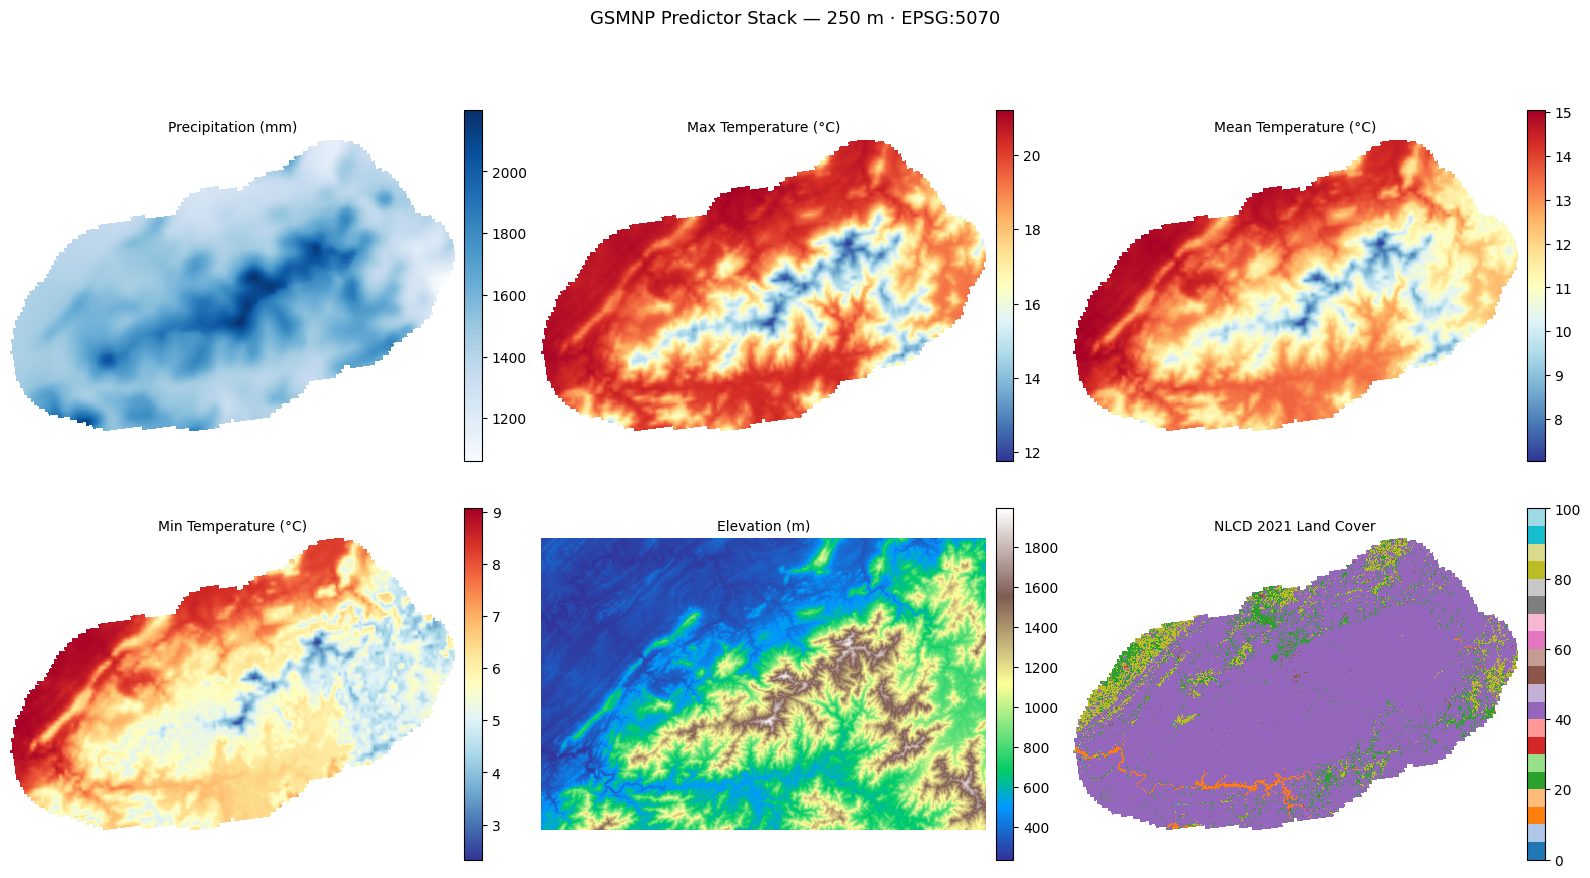

In [16]:
boundary_plot = boundary_albers.to_crs('EPSG:5070')

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

layer_spec = [
    ('ppt',       'Precipitation (mm)',          'Blues',     None),
    ('tmax',      'Max Temperature (°C)',         'RdYlBu_r',  None),
    ('tmean',     'Mean Temperature (°C)',        'RdYlBu_r',  None),
    ('tmin',      'Min Temperature (°C)',         'RdYlBu_r',  None),
    ('elevation', 'Elevation (m)',                'terrain',   None),
    ('landcover', 'NLCD 2021 Land Cover',         'tab20',     [0, 100]),
]

# Convert boundary to pixel coordinates for overlay
from rasterio.transform import rowcol

for ax, (key, title, cmap, vrange) in zip(axes.flat, layer_spec):
    arr = layers[key]
    kwargs = {'cmap': cmap, 'origin': 'upper', 'interpolation': 'nearest'}
    if vrange:
        kwargs['vmin'], kwargs['vmax'] = vrange
    im = ax.imshow(arr, **kwargs)
    ax.set_title(title, fontsize=10)
    ax.set_axis_off()
    plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02, shrink=0.8)

plt.suptitle('GSMNP Predictor Stack — 250 m · EPSG:5070', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## Stacking and Saving

Notebook 03 reads `env_predictors.tif` band-by-band to extract predictor values at each pixel and predict suitability. The band order is fixed: ppt, tmax, tmean, tmin, elevation, landcover. Band descriptions are embedded in the GeoTIFF metadata so the file is self-documenting.

All bands are written as float32. Land cover integer codes (11, 21, 41, etc.) are exactly representable in float32, so no precision is lost. LZW compression keeps file size manageable.

In [17]:
band_order = ['ppt', 'tmax', 'tmean', 'tmin', 'elevation', 'landcover']
band_desc  = [
    'Annual precipitation (mm)',
    'Mean annual max temperature (°C)',
    'Mean annual mean temperature (°C)',
    'Mean annual min temperature (°C)',
    'Elevation (m above sea level)',
    'NLCD 2021 land cover class',
]

stack = np.stack([layers[k] for k in band_order], axis=0)  # (6, H, W)

stack_path = out_dir / 'env_predictors.tif'
meta = {
    'driver':    'GTiff',
    'dtype':     'float32',
    'count':     len(band_order),
    'crs':       TARGET_CRS,
    'transform': target_xf,
    'width':     W,
    'height':    H,
    'nodata':    np.nan,
    'compress':  'lzw',
}
with rasterio.open(str(stack_path), 'w', **meta) as dst:
    for i, (arr, desc) in enumerate(zip(stack, band_desc), start=1):
        dst.write(arr, i)
        dst.update_tags(i, description=desc)

import os
size_mb = os.path.getsize(stack_path) / 1e6
print(f'Saved: {stack_path}')
print(f'  Bands:      {len(band_order)} ({", ".join(band_order)})')
print(f'  Shape:      {H} rows × {W} cols')
print(f'  Resolution: {RES} m  |  CRS: EPSG:5070')
print(f'  File size:  {size_mb:.1f} MB')


Saved: data/env_stack/env_predictors.tif
  Bands:      6 (ppt, tmax, tmean, tmin, elevation, landcover)
  Shape:      286 rows × 437 cols
  Resolution: 250 m  |  CRS: EPSG:5070
  File size:  2.2 MB


## Summary

### What was built

The environmental predictor stack for GSMNP:

| Band | Variable | Source | Native res |
|------|----------|--------|------------|
| 1 | Annual precipitation | PRISM 30-yr avg | ~800 m |
| 2 | Mean annual max temp | PRISM 30-yr avg | ~800 m |
| 3 | Mean annual mean temp | PRISM 30-yr avg | ~800 m |
| 4 | Mean annual min temp | PRISM 30-yr avg | ~800 m |
| 5 | Elevation | USGS 3DEP 1/3" | ~10 m |
| 6 | Land cover | NLCD 2021 | 30 m |

All layers are in EPSG:5070 at 250 m resolution, pixel-aligned to the same grid.

### What comes next

Notebook 03 takes two inputs from prior notebooks:

- `./data/slf_occurrences_cleaned.gpkg` — 8,835 presence points from notebook 01, spanning the SE US
- `./data/env_stack/env_predictors.tif` — the 6-band predictor stack from this notebook

The model is trained on environmental values extracted at presence points and at a set of background (pseudo-absence) points drawn from within a defined calibration area. It then predicts suitability across every pixel in `env_predictors.tif` to produce the habitat suitability surface. A fourth notebook overlays that surface with a survey effort bias layer to identify detection gaps in the park.